In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from langchain_community.document_loaders import Docx2txtLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import UnstructuredMarkdownLoader


splitter = RecursiveCharacterTextSplitter(
  chunk_size= 2000,
  chunk_overlap= 500
)

loader = UnstructuredMarkdownLoader('documents/real_estate_tax.md')


document_list  = loader.load_and_split(text_splitter= splitter)

document_list

[Document(metadata={'source': 'documents/real_estate_tax.md'}, page_content='종합부동산세법\n\n[시행 2023. 4. 18] [법률 제19342호, 2023. 4. 18, 일부개정] 기획재정부 (재산세제과) 044-215-4313\n\n제1장 총칙\n\n제1조(목적) 이 법은 고액의 부동산 보유자에 대하여 종합부동산세를 부과하여 부동산보유에 대한 조세부담의 형평성을 제고하고, 부동산의 가격안정을 도모함으로써 지방재정의 균형발전과 국민경제의 건전한 발전에 이바지함을 목적으로 한다.\n\n제2조(정의) 이 법에서 사용하는 용어의 정의는 다음 각호와 같다. <개정 2005. 12. 31., 2010. 3. 31., 2016. 1. 19., 2018. 12. 31., 2020. 6. 9., 2023. 3. 14.> 1. "시·군·구"란 함은 「지방자치법」 제2조에 따른 지방자치단체인 시·군 및 자치구(이하 "시·군·구"이라 한다)를 말한다. 2. "시장·군수·구청장"이라 함은 지방자치단체의 장인 시장·군수 및 자치구의 구청장(이하 "시장·군수·구청장"이라 한다)를 말한다. 3. "주택"이라 함은 「지방세법」 제104조제3호에 의한 주택을 말한다. 4. "토지"라 함은 「지방세법」 제104조제1호에 따른 토지를 말한다. 5. "주택분 재산세"라 함은 「지방세법」 제105조 및 제107조에 따라 주택에 대하여 부과하는 재산세를 말한다. 6. "토지분 재산세"라 함은 「지방세법」 제105조 및 제107조에 따라 토지에 대하여 부과하는 재산세를 말한다. <삭제 2005. 12. 31.> 7. "세대"라 함은 주택 또는 토지의 소유자 및 그 배우자와 그들과 생계를 같이하는 가족으로서 대통령령으로 정하는 것을 말한다. 8. "공시가격"이라 함은 「부동산 가격공시에 관한 법률」에 따라 가격이 공시되는 주택 및 토지에 대하여 같은 법에 따라 공시된 가격을 말한다. 다만, 같은 법에 따라 가격이 공시되지 아니한 경우에는 

In [4]:
from langchain_upstage import UpstageEmbeddings

embedding = UpstageEmbeddings(model = 'solar-embedding-1-large')

In [ ]:
from langchain_chroma import Chroma

# 처음 DB 생성할 때는 이 방식으로

# database = Chroma.from_documents(
#   documents= document_list,
#   embedding=embedding, 
#   collection_name='real_estate_tax',
#   persist_directory= './real_estate_tax_collection'
# )

In [ ]:
from langchain_upstage import UpstageEmbeddings
from langchain_chroma import Chroma
from langchain_anthropic import ChatAnthropic
from langsmith import Client

embedding = UpstageEmbeddings(model="solar-embedding-1-large")

database = Chroma(
    embedding_function = embedding,
    collection_name = 'real_estate_tax',
    persist_directory = './real_estate_tax_collection'
)
retriever = database.as_retriever(
    search_type= 'mmr',
    search_kwargs={
        'k': 4,
        'fetch_k': 10,
        'lambda_mult': 0.6
    }
)


client = Client()

llm = ChatAnthropic(
    model= 'claude-haiku-4-5-20251001',     # 개발중엔 하이쿠로..ㅠㅠ
    temperature= '0.1'
)

small_llm = ChatAnthropic(
    model= 'claude-haiku-4-5-20251001',
    temperature= '0.1'
)

# claude-opus-4-5-20251101
# claude-sonnet-4-5-20250929
# claude-haiku-4-5-20251001

In [35]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document


class AgentState(TypedDict):
    query: str # 사용자 질문
    answer: str # 세율
    tax_base_equation: str # 과세표준 계산 수식 
    tax_deduction: str # 공제액 
    market_ratio: str # 공정시장가액비율
    tax_base: str # 과세표준 계산
    

generate_prompt = client.pull_prompt("rlm/rag-prompt")

In [36]:
query = '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?'

## 병렬 구조 1. 과표 계산 수식만 return

In [37]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from typing import Literal
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import ChatPromptTemplate

tax_base_retrieval_chain = (
    {'context': retriever, 'question': RunnablePassthrough()} 
    | generate_prompt 
    | llm 
    | StrOutputParser()
)

tax_base_equation_prompt = ChatPromptTemplate.from_messages([
    ('system', '사용자의 질문에서 과세표준을 계산하는 방법을 수식으로 나타내주세요. 부연설명 없이 수식만 리턴해주세요'),
    ('human', '{tax_base_equation_information}')
])

tax_base_equation_chain = (
    {'tax_base_equation_information': RunnablePassthrough()}
    | tax_base_equation_prompt
    | llm
    | StrOutputParser()
)

tax_base_chain = {'tax_base_equation_information' : tax_base_retrieval_chain} | tax_base_equation_chain

def get_tax_base_equation(state: AgentState) -> AgentState:
    """
    종합부동산세 과세표준을 계산하는 수식을 가져옵니다.
    `node`로 활용되기 때문에 `state`를 인자로 받지만, 
    고정된 기능을 수행하기 때문에 `state`를 활용하지는 않습니다.

    Args:
        state (AgentState): 현재 에이전트의 상태를 나타내는 객체입니다.

    Returns:
        AgentState: 'tax_base_equation' 키를 포함하는 새로운 `state`를 반환합니다.
    """
    # 과세표준을 계산하는 방법을 묻는 질문을 정의합니다.
    tax_base_equation_question = '주택에 대한 종합부동산세 계산시 과세표준을 계산하는 방법을 수식으로 표현해서 알려주세요'
    
    # tax_base_chain을 사용하여 질문을 실행하고 결과를 얻습니다.
    tax_base_equation = tax_base_chain.invoke(tax_base_equation_question)
    
    # state에서 'tax_base_equation' 키에 대한 값을 반환합니다.
    return {'tax_base_equation': tax_base_equation}

In [ ]:
# get_tax_base_equation({})

{'tax_base_equation': '**과세표준 = (주택 공시가격 합산액 - 공제금액) × 공정시장가액비율**'}

## 병렬구조 2. 공제액 계산

In [38]:
tax_deduction_chain = (
    {'context': retriever, 'question': RunnablePassthrough()} 
    | generate_prompt 
    | llm 
    | StrOutputParser()
)

def get_tax_deduction(state: AgentState) -> AgentState:
    """
    종합부동산세 공제금액에 관한 정보를 가져옵니다.
    `node`로 활용되기 때문에 `state`를 인자로 받지만, 
    고정된 기능을 수행하기 때문에 `state`를 활용하지는 않습니다.

    Args:
        state (AgentState): 현재 에이전트의 state를 나타내는 객체입니다.

    Returns:
        AgentState: 'tax_deduction' 키를 포함하는 새로운 state를 반환합니다.
    """
    # 공제금액을 묻는 질문을 정의합니다.
    tax_deduction_question = '주택에 대한 종합부동산세 계산시 공제금액을 알려주세요'
    
    # tax_deduction_chain을 사용하여 질문을 실행하고 결과를 얻습니다.
    tax_deduction = tax_deduction_chain.invoke(tax_deduction_question)
    
    # state에서 'tax_deduction' 키에 대한 값을 반환합니다.
    return {'tax_deduction': tax_deduction}

In [9]:
# get_tax_deduction({})

## 병렬구조3. 공정시장가액비율 가져오기

In [39]:
from langchain_community.tools import TavilySearchResults
from datetime import date

tavily_search_tool = TavilySearchResults(
    max_results=7,
    search_depth='advanced',
    include_answer=True,
    include_raw_content=True,
    include_images=False
    # include_domains=
    # exclude_domains=
    # name=
    # description=
    # args_schema=
)

tax_market_ratio_prompt = ChatPromptTemplate.from_messages([
    ('system', f'아래 정보를 기반으로 공정시장 가액비율을 계산해주세요\n\nContext:\n{{context}}'),
    ('human', '{query}')
])

def get_market_ratio(state: AgentState) -> AgentState:
    """
    web 검색을 통해 주택 공시가격에 대한 공정시장가액비율을 가져옵니다.
    `node`로 활용되기 때문에 `state`를 인자로 받지만, 
    고정된 기능을 수행하기 때문에 `state`를 활용하지는 않습니다.
    
    Args:
        state (AgentState): 현재 에이전트의 state를 나타내는 객체입니다.

    Returns:
        AgentState: 'market_ratio' 키를 포함하는 새로운 state를 반환합니다.
    """
    # 오늘 날짜에 해당하는 공정시장가액비율을 묻는 쿼리를 정의합니다.
    query = f'오늘 날짜:({date.today()})에 해당하는 주택 공시가격 공정시장가액비율은 몇%인가요?'
    
    # tavily_search_tool을 사용하여 쿼리를 실행하고 컨텍스트를 얻습니다.
    context = tavily_search_tool.invoke(query)
    
    # tax_market_ratio_chain을 구성하여 쿼리와 컨텍스트를 처리합니다.
    tax_market_ratio_chain = (
        tax_market_ratio_prompt
        | llm
        | StrOutputParser()
    )
    
    # tax_market_ratio_chain을 사용하여 시장 비율을 계산합니다.
    market_ratio = tax_market_ratio_chain.invoke({'context': context, 'query': query})
    
    # state에서 'market_ratio' 키에 대한 값을 반환합니다.
    return {'market_ratio': market_ratio}

In [ ]:
# get_market_ratio({})

{'market_ratio': '# 2026년 주택 공정시장가액비율\n\n## 현행 공정시장가액비율 (2025년 적용, 2026년에도 유지 예정)\n\n### 1세대 1주택자 (특례 적용)\n\n| 공시가격 구간 | 공정시장가액비율 |\n|--------------|------------------|\n| **3억원 이하** | **43%** |\n| **3억원 초과 ~ 6억원 이하** | **44%** |\n| **6억원 초과** | **45%** |\n\n### 다주택자 및 법인\n\n| 구분 | 공정시장가액비율 |\n|------|------------------|\n| 주택 | **60%** |\n\n---\n\n## 참고사항\n\n- **1주택자 특례**는 2023년부터 한시적으로 적용되어 왔으며, 2025년에도 동일하게 연장 적용됩니다\n- 행정안전부가 2025년 4월 「지방세법 시행령」 개정안을 입법예고하여 **2025년 재산세 부과부터 적용** 예정입니다\n- 토지 및 건축물의 공정시장가액비율은 **70%**입니다'}

## 병렬 Node들을 합치는 Node

In [41]:
from langchain_core.prompts import PromptTemplate

tax_base_calculate_prompt = ChatPromptTemplate.from_messages(
    [
        ('system',"""
주어진 내용을 기반으로 과세표준을 계산해주세요

과세표준 계산 공식: {tax_base_equation}
공제금액: {tax_deduction}
공정시장가액비율: {market_ratio}"""),
        ('human', '사용자 주택 공시가격 정보: {query}')
    ]
)

def calculate_tax_base(state: AgentState)-> dict[str, str]:
    tax_base_equation = state['tax_base_equation']
    tax_deduction = state['tax_deduction']
    market_ratio = state['market_ratio']
    query = state['query']
    
    tax_base_calculate_chain = (
        tax_base_calculate_prompt
        | llm
        | StrOutputParser()
    )
    
    tax_base = tax_base_calculate_chain.invoke({
        'tax_base_equation': tax_base_equation,
        'tax_deduction': tax_deduction,
        'market_ratio': market_ratio,
        'query': query
    })

    
    return {'tax_base': tax_base}

In [43]:
tax_calculate_prompt = ChatPromptTemplate.from_messages([
    ('system', '당신은 종합부동산세 계산 전문가입니다. 아래 문서를 참고하여 사용자의 질문에 대한 종합부동산세를 계산해주세요\n\n종합부동산세 세율: {context}'),
    ('human', '''과세표준과 사용자가 소지한 주택의 수가 아래와 같을 때 종합부동산세를 계산해 주세요.

과세표준: {tax_base}
주택 수: {query}''')
])

tax_calculate_chain =(
    tax_calculate_prompt
    |llm
    | StrOutputParser()
)

def calculate_tax(state: AgentState)-> dict[str, str]:
    query = state['query']
    tax_base = state['tax_base']
    context = retriever.invoke('종합부동산세 제9조 주택 세율표 2주택 3주택')        # 사실 이 부분은 retrieve 할 필요 없이 하드코딩 해도 괜찮다..


    tax = tax_calculate_chain.invoke({
        'query': query,
        'tax_base': tax_base,
        'context': context
    })
    
    return {'answer': tax}

## Build 시작

In [44]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(AgentState)


graph_builder.add_node('get_tax_base_equation', get_tax_base_equation)
graph_builder.add_node('get_tax_deduction', get_tax_deduction)
graph_builder.add_node('get_market_ratio', get_market_ratio)
graph_builder.add_node('calculate_tax_base', calculate_tax_base)
graph_builder.add_node('calculate_tax', calculate_tax)


graph_builder.add_edge(START, 'get_tax_base_equation')
graph_builder.add_edge(START, 'get_tax_deduction')
graph_builder.add_edge(START, 'get_market_ratio')

graph_builder.add_edge('get_tax_base_equation', 'calculate_tax_base')
graph_builder.add_edge('get_tax_deduction', 'calculate_tax_base')
graph_builder.add_edge('get_market_ratio', 'calculate_tax_base')


graph_builder.add_edge('calculate_tax_base', 'calculate_tax')
graph_builder.add_edge('calculate_tax', END)


graph = graph_builder.compile()

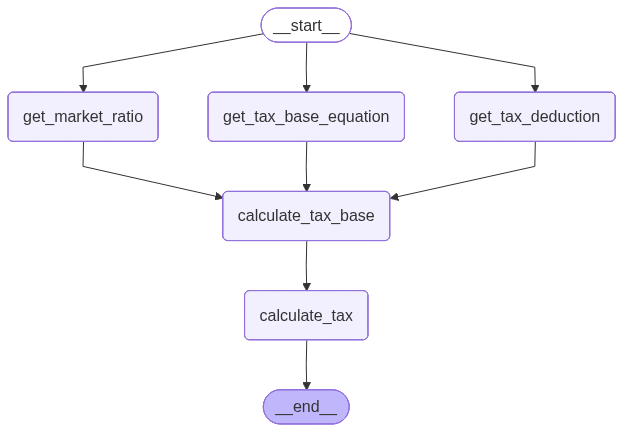

In [45]:
from IPython.display import display, Image

display(Image(graph.get_graph(xray=False).draw_mermaid_png()))

In [47]:
query = '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?'
initial_state = {'query': query}
response = graph.invoke(initial_state)

In [33]:
display(Markdown(response['answer']))

# 종합부동산세 계산 결과

## 📋 기본 정보 확인

| 항목 | 내용 |
|------|------|
| **주택 수** | 3채 (5억 + 10억 + 20억) |
| **과세표준** | **15억 6,000만원** |
| **적용 세율표** | **3주택 이상 소유자** |

---

## 🧮 세액 계산

### 적용 세율 구간 확인

3주택 이상 소유자의 경우, 과세표준 **15억 6,000만원**은 다음 구간에 해당합니다:

> **12억 원 초과 25억 원 이하**: 960만원 + (12억원 초과 금액 × 2.0%)

---

### 계산 과정

| 단계 | 계산 | 금액 |
|------|------|------|
| ① 과세표준 | - | 15억 6,000만원 |
| ② 12억원 초과 금액 | 15억 6,000만원 - 12억원 | **3억 6,000만원** |
| ③ 초과분 세액 | 3억 6,000만원 × 20/1000 | **720만원** |
| ④ 기본 세액 | - | **960만원** |
| ⑤ **종합부동산세액** | 960만원 + 720만원 | **1,680만원** |

---

## 📊 최종 결과

$$\text{종합부동산세} = 960만원 + (3억6,000만원 \times 0.02) = \textbf{1,680만원}$$

---

## ⚠️ 참고사항

| 항목 | 내용 |
|------|------|
| **재산세 공제** | 이미 납부한 주택분 재산세는 위 세액에서 공제됩니다 |
| **세부담 상한** | 전년도 총세액의 150%를 초과하는 경우 초과분은 면제 |
| **농어촌특별세** | 종합부동산세액의 20%가 별도 부과됩니다 (약 336만원) |

### 💰 예상 총 납부액 (농특세 포함)

$$1,680만원 + 336만원 = \textbf{약 2,016만원}$$

> **※ 실제 납부세액은 재산세 공제 후 금액이며, 세부담 상한 적용 여부에 따라 달라질 수 있습니다.**

In [ ]:
## 하고 싶은 것 ##

# System prompt 경량화 - 법률 전문을 넣지 말고, retrieve된 관련 조문만
# Context 재사용 - 병렬 노드들이 같은 문서를 각각 retrieve하지 않도록

# 오늘 배운 병렬 기법으로 주요 기능들을 module화 해서 
# 다른 Agent가 호출할 수 있는 Tool로 만드는 것!

# 작은 모델로 대체할 수 있는 작업은 작은 모델로 대체하기!